In [1]:
!pip install -q scikit-learn matplotlib seaborn

In [2]:
import numpy as np
import json
import os
import joblib # For saving the trained model

Visualization tools for clustering check

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC # The industry standard classifier for embeddings
from sklearn.metrics import accuracy_score, classification_report

loading the data

In [5]:
X = np.load("my_X_arcface.npy")
y = np.load("my_y_arcface.npy")
print(" Embeddings (X) and Labels (y) loaded successfully.")
print(f"   -> Total samples: {X.shape[0]}")
print(f"   -> Embedding dimensions: {X.shape[1]} (ArcFace Standard)")

 Embeddings (X) and Labels (y) loaded successfully.
   -> Total samples: 4060
   -> Embedding dimensions: 512 (ArcFace Standard)


In [6]:
with open("celebrity_name_mapping.json", 'r') as f:
        # Convert string keys back to integers for easier usage
        mapping_raw = json.load(f)
        idx_to_name = {int(k): v.replace("_", " ") for k, v in mapping_raw.items()}
print(f" Name mapping loaded for {len(idx_to_name)} celebrities.")

 Name mapping loaded for 997 celebrities.


In [7]:
print("Performing quality check on embeddings (Visualizing top 10 classes)...")

# 1. Find top 10 most frequent classes to visualize
from collections import Counter
top_10_indices = [label for label, count in Counter(y).most_common(10)]

# 2. Filter data to just these top 10
mask = np.isin(y, top_10_indices)
X_viz = X[mask]
y_viz = y[mask]
names_viz = [idx_to_name[idx] for idx in y_viz]

Performing quality check on embeddings (Visualizing top 10 classes)...


In [8]:
# 3. Compress 512D -> 2D using PCA for plotting
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_viz)


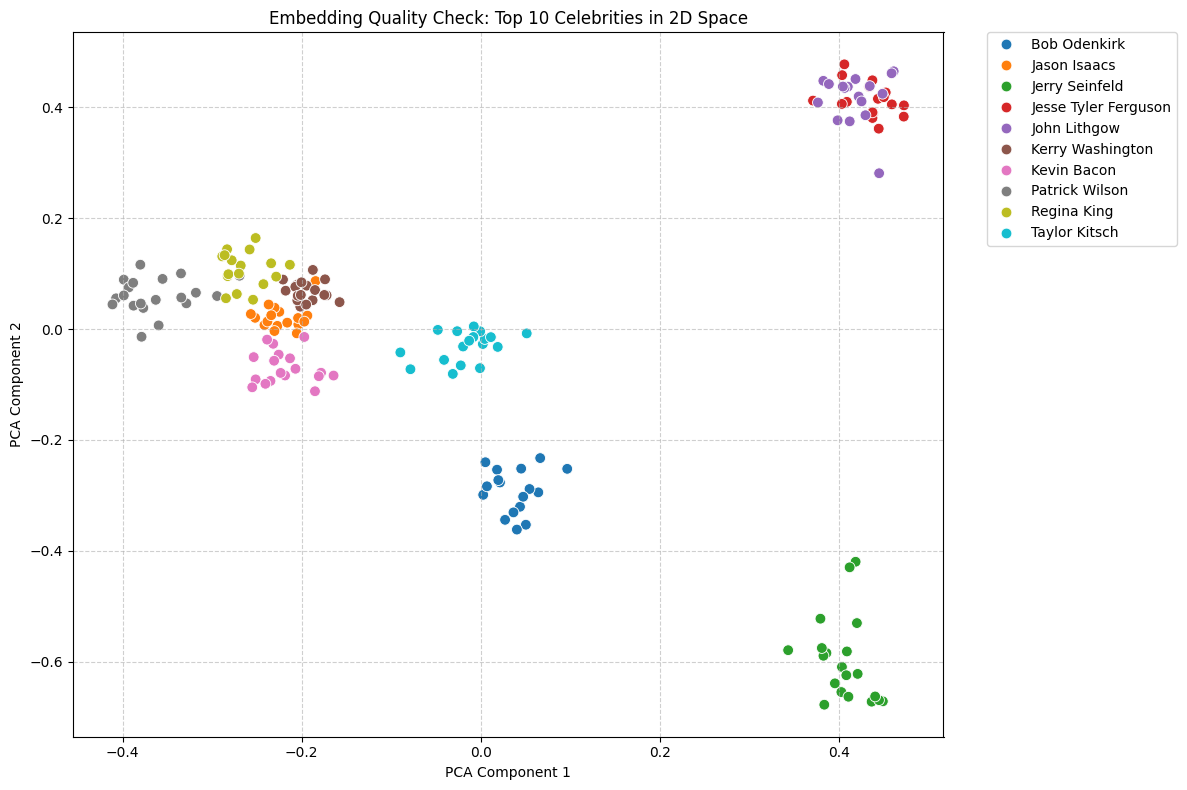

In [9]:
# 4. Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=names_viz, palette="tab10", s=60)
plt.title("Embedding Quality Check: Top 10 Celebrities in 2D Space")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Spliting data for training

In [10]:
import numpy as np
import pandas as pd

# y = labels (person IDs)

label_counts = pd.Series(y).value_counts()


valid_labels = label_counts[label_counts >= 2].index

mask = np.isin(y, valid_labels)

X = X[mask]
y = y[mask]

print("Remaining identities:", len(np.unique(y)))


Remaining identities: 650


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(" Data split complete.")
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Testing samples:  {X_test.shape[0]}")

 Data split complete.
   Training samples: 3104
   Testing samples:  777


train the classifier in svm and later we will use on fully connected

In [12]:
clf = LinearSVC(C=1.0, dual='auto', random_state=42)

print("Starting training (fitting to X_train)...")
clf.fit(X_train, y_train)


Starting training (fitting to X_train)...


LinearSVC(random_state=42)

In [13]:
model_filename = "celebrity_svm_model.pkl"
print(f"Saving trained classifier to '{model_filename}'...")

# Use joblib to efficiently save the sklearn model
joblib.dump(clf, model_filename)

Saving trained classifier to 'celebrity_svm_model.pkl'...


['celebrity_svm_model.pkl']

Training fully connected classifier

In [14]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
import numpy as np




# 1. Re-encode labels to be 0-indexed for to_categorical
# Fit LabelEncoder on all unique labels present in the filtered dat

In [15]:
le = LabelEncoder()
all_filtered_labels = np.unique(np.concatenate((y_train, y_test)))
le.fit(all_filtered_labels)
y_train_encoded = le.transform(y_train)
y_test_encoded = le.transform(y_test)

# 2. Convert integer labels (y_train_encoded) to one-hot encoding for Keras
num_classes = len(le.classes_)
y_train_one_hot = to_categorical(y_train_encoded, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test_encoded, num_classes=num_classes)
input_dim = X_train.shape[1] # This should be 512

In [16]:
le = LabelEncoder()
all_filtered_labels = np.unique(np.concatenate((y_train, y_test)))
le.fit(all_filtered_labels)
y_train_encoded = le.transform(y_train)
y_test_encoded = le.transform(y_test)

Define the model architeture

In [17]:
fc_model = Sequential([
    # Input layer (512 features) -> 512 neurons
    Dense(512, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3), # Dropout helps prevent overfitting
    # Hidden layer -> 256 neurons
    Dense(256, activation='relu'),
    Dropout(0.3),
    # Output layer -> num_classes neurons (one for each class)
    # softmax ensures the output is a probability distribution
    Dense(num_classes, activation='softmax')
], name='FC_Classifier')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
# 4. Compile the model
fc_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train the model
print("Starting training of FC model...")
history = fc_model.fit(
    X_train, y_train_one_hot,
    epochs=20, # Start with 20 epochs
    batch_size=32,
    validation_data=(X_test, y_test_one_hot),
    verbose=0
)

Starting training of FC model...


In [19]:
loss, accuracy = fc_model.evaluate(X_test, y_test_one_hot, verbose=0)
print(f"FC Model Test Accuracy: {accuracy*100:.2f}%")

FC Model Test Accuracy: 96.91%


In [20]:
from sklearn.neighbors import KNeighborsClassifier

print("Training K-Nearest Neighbors (KNN) Classifier (Model #3)...")

# 1. Initialize KNN (k=3 means it looks at the 3 closest faces)
knn_model = KNeighborsClassifier(n_neighbors=3, metric='euclidean')

# 2. Train the model
knn_model.fit(X_train, y_train)

# 3. Quick Score Check
knn_acc = knn_model.score(X_test, y_test)
print(f" KNN Training Complete.")
print(f"KNN Test Accuracy: {knn_acc*100:.2f}%")

Training K-Nearest Neighbors (KNN) Classifier (Model #3)...
 KNN Training Complete.
KNN Test Accuracy: 96.78%


In [21]:
fc_model.save('celebrity_fc_model.h5')



In [22]:
fc_model.save('celebrity_fc_model.h5')

In [23]:
svm_accuracy = clf.score(X_test, y_test)
fc_accuracy = accuracy # From your previous cell
print(f"1. Linear SVM Accuracy:      {svm_accuracy*100:.2f}%")
print(f"2. Fully Connected Accuracy: {fc_accuracy*100:.2f}%")

if svm_accuracy > fc_accuracy:
    print("\n The Linear SVM is the winner for this dataset.")
else:
    print("\The Deep Learning FC model is the winner.")

1. Linear SVM Accuracy:      97.68%
2. Fully Connected Accuracy: 96.91%

 The Linear SVM is the winner for this dataset.


<>:9: SyntaxWarning: invalid escape sequence '\T'
<>:9: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipython-input-1818040818.py:9: SyntaxWarning: invalid escape sequence '\T'
  print("\The Deep Learning FC model is the winner.")


Arcface+SVM

In [24]:
y_pred_fc = np.argmax(fc_model.predict(X_test), axis=1)


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


Accuracy

In [25]:
from sklearn.metrics import accuracy_score
fc_accuracy = accuracy_score(y_test_encoded, y_pred_fc)
print("FC Accuracy:", fc_accuracy)


FC Accuracy: 0.9691119691119691


Precision & Recall

In [26]:
print("FC Classification Report:")
print(classification_report(y_test_encoded, y_pred_fc, zero_division=0))


FC Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         3
          16       1.00      1.00      1.00         1
          18       1.00      1.00      1.00         2
          19       1.00      1.00      1.00         1
          20       1.00      1.00      1.00         1
          21       1.00      1.00      1.00         1
 

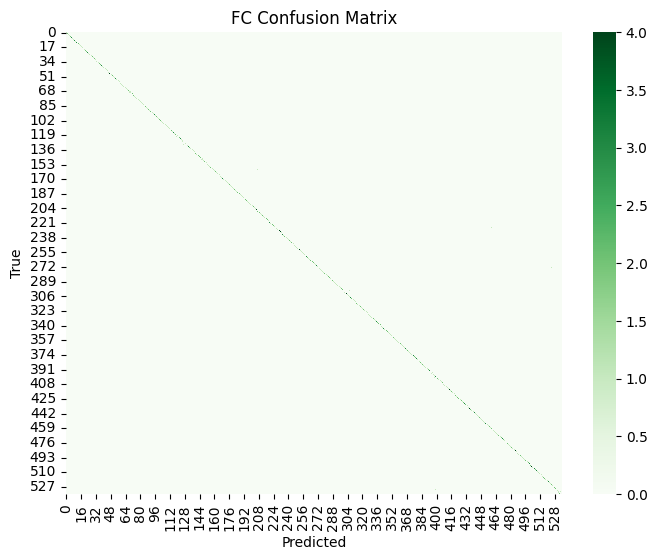

In [29]:
from sklearn.metrics import confusion_matrix

cm_fc = confusion_matrix(y_test_encoded, y_pred_fc)

plt.figure(figsize=(8,6))
sns.heatmap(cm_fc, cmap="Greens", cbar=True)
plt.title("FC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()